# D2C Customer Intelligence & Retention Prioritization

## Part 2: Advanced RFM Segmentation & Customer Behavior Analysis

### Objective

This notebook builds a business-oriented customer intelligence framework using RFM analysis, churn behavior, engagement activity, and support interactions to identify valuable customers, retention risks, and intervention opportunities.

The analysis focuses on:

- leakage-safe RFM calculation,
- churn-aware segmentation,
- customer-value prioritization,
- engagement decline detection,
- support dissatisfaction analysis,
- and retention-focused business intelligence.

---

**Author:** Prateek Parmar

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_style("whitegrid")

In [47]:
# Dataset Loading

data_path = r"C:\D2C_Customer_Churn_Capstone\d2c churn data package\\"

customers = pd.read_csv(data_path + "customers.csv")

try:
    orders = pd.read_csv(data_path + "orders_clean.csv")
    print("Loaded orders_clean.csv")
except FileNotFoundError:
    orders = pd.read_csv(data_path + "orders.csv")
    print("WARNING: orders_clean.csv not found, falling back to orders.csv")

# Pick the monetary column produced by Part 1 cleaning (capped at p99) if present
AMT_COL = "gross_amount_capped" if "gross_amount_capped" in orders.columns else "gross_amount"
print(f"Using monetary column: {AMT_COL}")

support_tickets = pd.read_csv(data_path + "support_tickets.csv")
web_events = pd.read_csv(data_path + "web_events_snapshot.csv")
churn_labels = pd.read_csv(data_path + "churn_labels.csv")
intervention_history = pd.read_csv(data_path + "intervention_history.csv")

print("Datasets loaded successfully")


Using monetary column: gross_amount
Datasets loaded successfully


In [7]:
print("Customers Shape:", customers.shape)
print("Orders Shape:", orders.shape)
print("Support Tickets Shape:", support_tickets.shape)
print("Web Events Shape:", web_events.shape)
print("Churn Labels Shape:", churn_labels.shape)
print("Intervention History Shape:", intervention_history.shape)

Customers Shape: (2400, 9)
Orders Shape: (10009, 10)
Support Tickets Shape: (1921, 8)
Web Events Shape: (2400, 10)
Churn Labels Shape: (2400, 4)
Intervention History Shape: (2400, 5)


In [8]:
customers.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


# Snapshot Integrity & Leakage Prevention

In [9]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
churn_labels['snapshot_date'] = pd.to_datetime(churn_labels['snapshot_date'])

print("Date conversion completed")

Date conversion completed


In [10]:
SNAPSHOT_DATE = "2025-09-30"

orders_pre_snapshot = orders[
    orders["order_date"] <= SNAPSHOT_DATE
]

post_snapshot_orders = orders[
    orders["order_date"] > SNAPSHOT_DATE
]

print("Original orders shape:", orders.shape)
print("Pre-snapshot orders shape:", orders_pre_snapshot.shape)
print("Post-snapshot orders shape:", post_snapshot_orders.shape)

Original orders shape: (10009, 10)
Pre-snapshot orders shape: (8137, 10)
Post-snapshot orders shape: (1872, 10)


In [11]:
post_snapshot_orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
7,ORD008129,CUST00002,2025-10-24,Skin Care,1,562.21,0.16,1,0,5.0
8,ORD008130,CUST00002,2025-10-26,Skin Care,1,569.89,0.18,4,0,4.0
15,ORD008132,CUST00005,2025-10-29,Hair Care,1,379.14,0.34,4,0,2.0
16,ORD008131,CUST00005,2025-11-19,Baby Care,3,980.38,0.22,4,0,4.0
22,ORD008133,CUST00006,2025-10-06,Baby Care,1,217.30,0.38,4,0,4.0


# RFM Metric Creation

In [12]:
reference_date = orders_pre_snapshot['order_date'].max()

print("Reference Date:", reference_date)

Reference Date: 2025-09-30 00:00:00


In [13]:
rfm = orders_pre_snapshot.groupby('customer_id').agg({
    'order_date': lambda x: (reference_date - x.max()).days,
    'order_id': 'count',
    'gross_amount': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST00001,107,6,2955.57
1,CUST00002,40,1,581.00
2,CUST00003,171,1,649.98
3,CUST00004,131,1,1604.04
4,CUST00005,38,4,2550.91


In [14]:
rfm.describe()

,Recency,Frequency,Monetary
count,2400.000000,2400.000000,2400.000000
mean,87.375833,3.390417,2549.655729
std,80.137473,2.383350,2129.104340
min,0.000000,1.000000,149.000000
25%,25.000000,1.000000,955.380000
50%,66.000000,3.000000,2012.020000
75%,129.000000,5.000000,3566.080000
max,562.000000,16.000000,27215.920000


# RFM Distribution Analysis

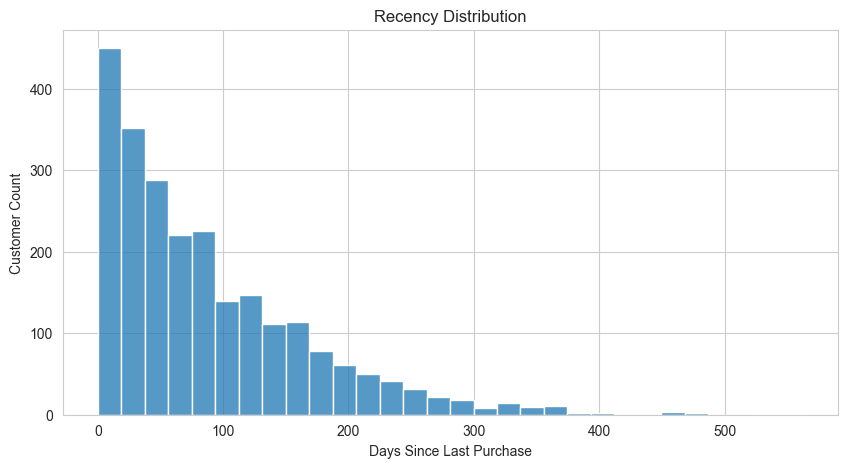

In [15]:
#Recency Distribution

plt.figure(figsize=(10,5))

sns.histplot(rfm['Recency'], bins=30)

plt.title("Recency Distribution")

plt.xlabel("Days Since Last Purchase")

plt.ylabel("Customer Count")

plt.show()

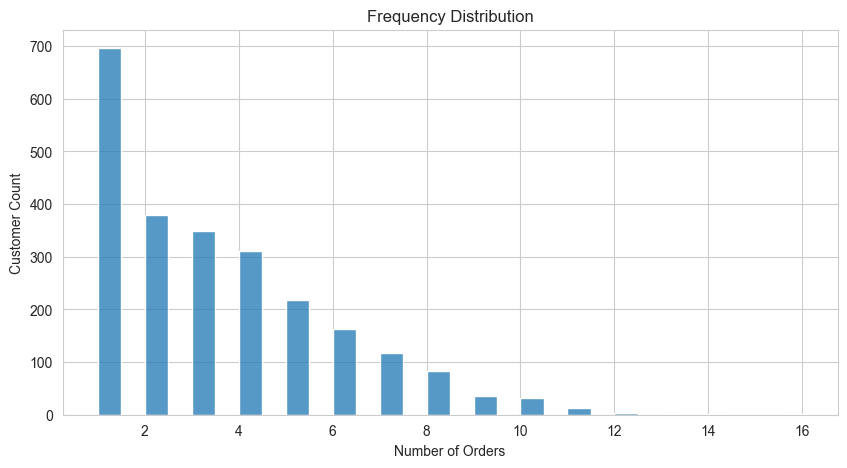

In [16]:
#Frequency Distribution

plt.figure(figsize=(10,5))

sns.histplot(rfm['Frequency'], bins=30)

plt.title("Frequency Distribution")

plt.xlabel("Number of Orders")

plt.ylabel("Customer Count")

plt.show()

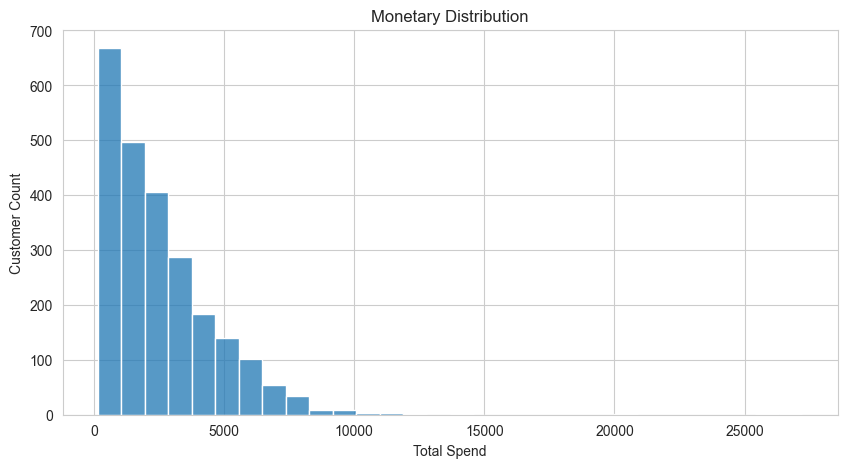

In [17]:
#Monetary Distribution

plt.figure(figsize=(10,5))

sns.histplot(rfm['Monetary'], bins=30)

plt.title("Monetary Distribution")

plt.xlabel("Total Spend")

plt.ylabel("Customer Count")

plt.show()

# RFM Scoring

In [18]:
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [19]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,CUST00001,107,6,2955.57,2,5,4,254
1,CUST00002,40,1,581.00,4,1,1,411
2,CUST00003,171,1,649.98,1,1,1,111
3,CUST00004,131,1,1604.04,2,1,3,213
4,CUST00005,38,4,2550.91,4,3,3,433


# Business-Oriented Customer Segmentation

In [20]:
def segment_customer(row):

    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    # Champions
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # Loyal Customers
    elif f >= 4 and m >= 3:
        return "Loyal Customers"

    # Big Spenders
    elif m >= 5 and f <= 3:
        return "Big Spenders"

    # At Risk
    elif r <= 2 and f <= 2:
        return "At Risk"

    # Recent Customers
    elif r >= 4 and f <= 2:
        return "Recent Customers"

    # Regular Customers
    else:
        return "Regular Customers"


In [21]:
rfm['Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers
2,CUST00003,171,1,649.98,1,1,1,111,At Risk
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk
4,CUST00005,38,4,2550.91,4,3,3,433,Regular Customers


# Segment Business Analysis

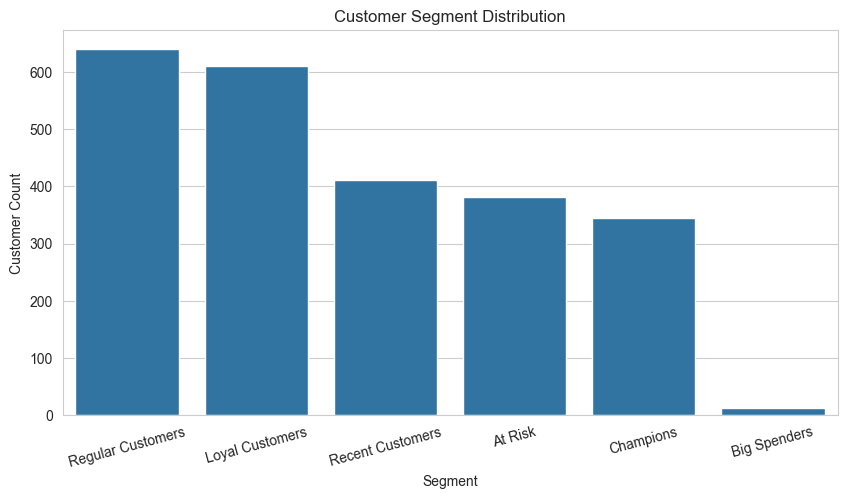

In [22]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Customer Segment Distribution")

plt.xlabel("Segment")
plt.ylabel("Customer Count")

plt.xticks(rotation=15)

plt.show()

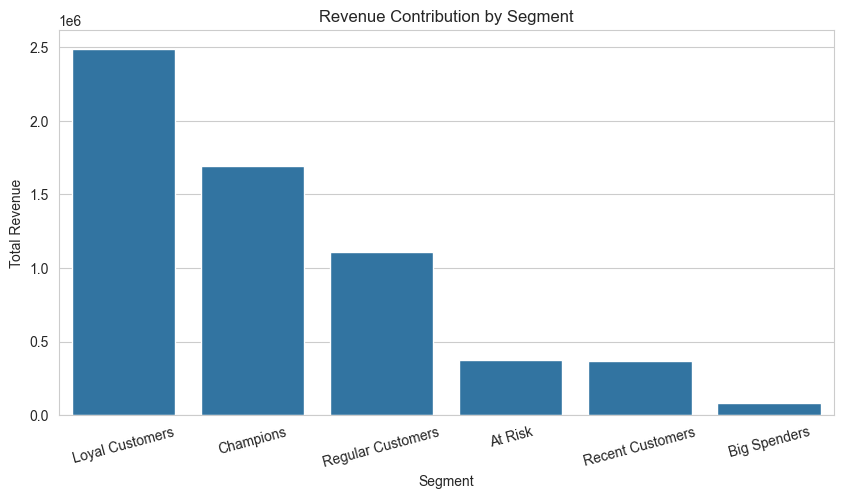

In [23]:
#Revenue Contribution by Segment

segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values
)

plt.title("Revenue Contribution by Segment")

plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=15)

plt.show()

In [24]:
#Average Monetary Value

segment_avg_spend = (
    rfm.groupby('Segment')['Monetary']
    .mean()
    .sort_values(ascending=False)
)

segment_avg_spend

Segment
Big Spenders         6271.371538
Champions            4920.766366
Loyal Customers      4085.348082
Regular Customers    1726.272434
At Risk               986.730105
Recent Customers      901.107445
Name: Monetary, dtype: float64

# Segment vs Churn Analysis

In [25]:
rfm_churn = rfm.merge(
    churn_labels[['customer_id', 'churn_next_60d']],
    on='customer_id',
    how='left'
)

rfm_churn.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,churn_next_60d
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers,1
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers,0
2,CUST00003,171,1,649.98,1,1,1,111,At Risk,1
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk,1
4,CUST00005,38,4,2550.91,4,3,3,433,Regular Customers,0


In [26]:
segment_churn = (
    rfm_churn.groupby('Segment')['churn_next_60d']
    .mean()
    .sort_values(ascending=False)
)

segment_churn

Segment
At Risk              0.860892
Big Spenders         0.615385
Loyal Customers      0.557377
Regular Customers    0.502340
Recent Customers     0.226277
Champions            0.104651
Name: churn_next_60d, dtype: float64

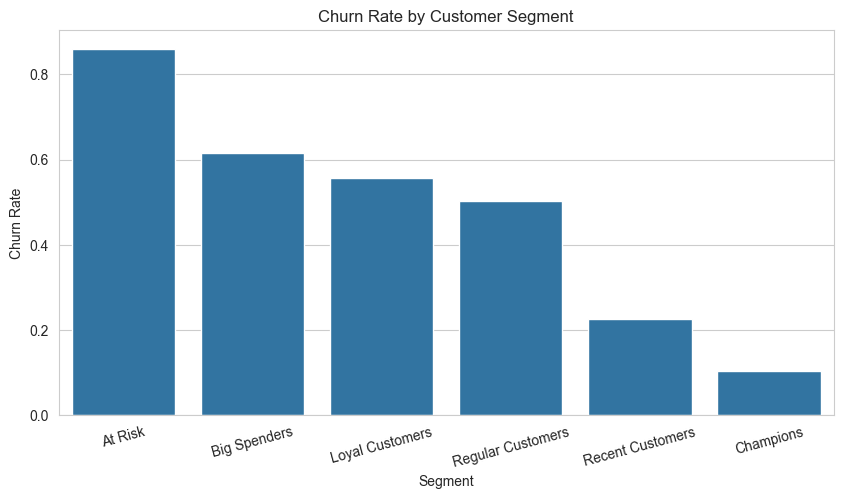

In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_churn.index,
    y=segment_churn.values
)

plt.title("Churn Rate by Customer Segment")

plt.xlabel("Segment")
plt.ylabel("Churn Rate")

plt.xticks(rotation=15)

plt.show()

In [28]:
high_value_risk = rfm_churn[
    (rfm_churn['Segment'].isin(['Champions', 'Big Spenders'])) &
    (rfm_churn['churn_next_60d'] == 1)
]

high_value_risk.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,churn_next_60d
19,CUST00020,368,3,4487.95,1,3,5,135,Big Spenders,1
50,CUST00051,210,4,4444.30,1,3,5,135,Big Spenders,1
109,CUST00110,35,6,3922.07,4,5,4,454,Champions,1
183,CUST00184,14,5,5072.85,5,4,5,545,Champions,1
187,CUST00188,29,7,5810.17,4,5,5,455,Champions,1


# Digital Engagement Integration

In [29]:
rfm_engagement = rfm.merge(
    web_events,
    on='customer_id',
    how='left'
)

rfm_engagement.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,171,1,649.98,1,1,1,111,At Risk,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,38,4,2550.91,4,3,3,433,Regular Customers,2025-09-30,18,95,4,1,1,3,1,9


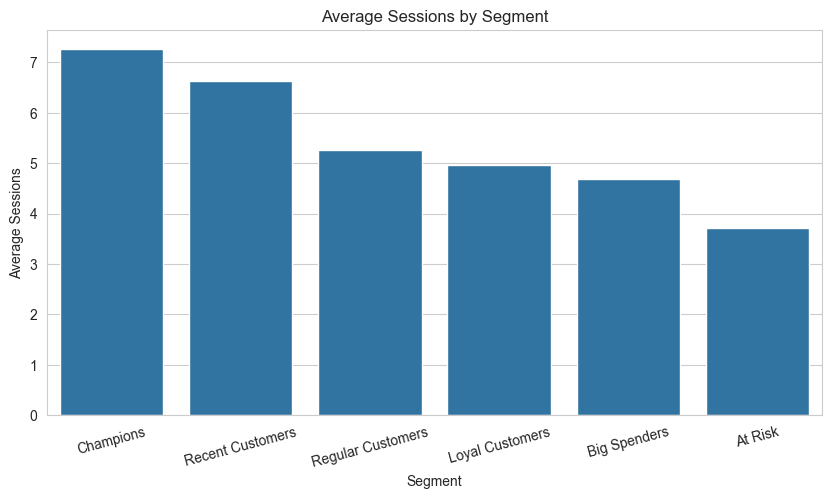

In [30]:
segment_sessions = (
    rfm_engagement.groupby('Segment')['sessions_30d']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_sessions.index,
    y=segment_sessions.values
)

plt.title("Average Sessions by Segment")

plt.xlabel("Segment")
plt.ylabel("Average Sessions")

plt.xticks(rotation=15)

plt.show()

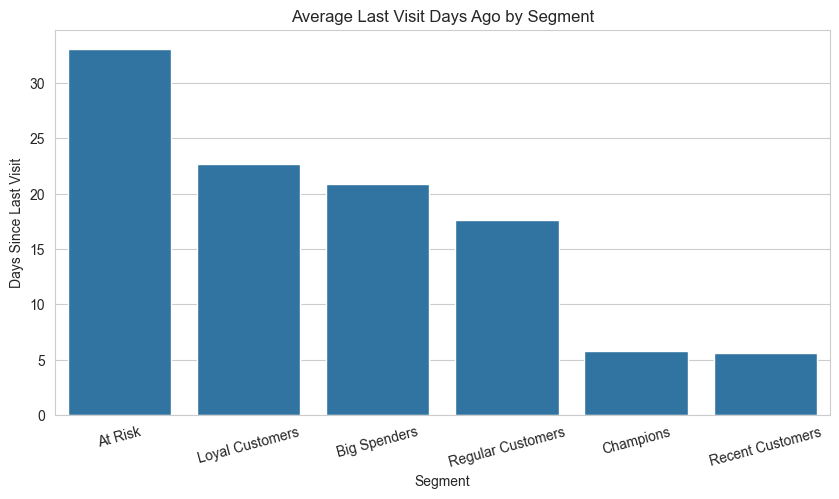

In [31]:
segment_last_visit = (
    rfm_engagement.groupby('Segment')['last_visit_days_ago']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_last_visit.index,
    y=segment_last_visit.values
)

plt.title("Average Last Visit Days Ago by Segment")

plt.xlabel("Segment")
plt.ylabel("Days Since Last Visit")

plt.xticks(rotation=15)

plt.show()

In [32]:
silent_risk_customers = rfm_engagement[
    (rfm_engagement['Segment'].isin(['Champions', 'Big Spenders'])) &
    (rfm_engagement['sessions_30d'] < rfm_engagement['sessions_30d'].median())
]

silent_risk_customers.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
19,CUST00020,368,3,4487.95,1,3,5,135,Big Spenders,2025-09-30,0,0,0,0,0,0,0,60
28,CUST00029,18,8,5252.90,5,5,5,555,Champions,2025-09-30,1,6,0,0,0,0,0,0
96,CUST00097,1,7,4703.46,5,5,5,555,Champions,2025-09-30,0,0,0,0,0,0,0,0
109,CUST00110,35,6,3922.07,4,5,4,454,Champions,2025-09-30,4,15,1,1,0,0,0,8
111,CUST00112,0,8,5576.25,5,5,5,555,Champions,2025-09-30,4,15,1,1,0,0,0,0


# Support Experience Integration

In [33]:
support_summary = (
    support_tickets.groupby('customer_id')
    .agg({
        'sentiment_score': 'mean',
        'reopened': 'sum',
        'resolution_hours': 'mean'
    })
    .reset_index()
)

support_summary.head()

,customer_id,sentiment_score,reopened,resolution_hours
0,CUST00001,0.14,0,4.35
1,CUST00002,0.00,0,1.00
2,CUST00005,-1.00,0,37.70
3,CUST00006,-0.68,1,17.60
4,CUST00008,0.08,0,6.00


In [34]:
rfm_support = rfm.merge(
    support_summary,
    on='customer_id',
    how='left'
)

rfm_support.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,sentiment_score,reopened,resolution_hours
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers,0.14,0.0,4.35
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers,0.00,0.0,1.00
2,CUST00003,171,1,649.98,1,1,1,111,At Risk,NaN,NaN,NaN
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk,NaN,NaN,NaN
4,CUST00005,38,4,2550.91,4,3,3,433,Regular Customers,-1.00,0.0,37.70


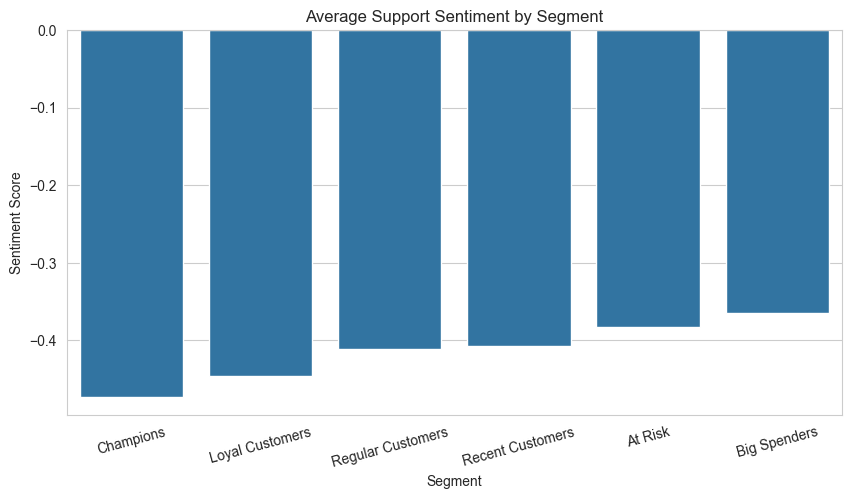

In [35]:
segment_sentiment = (
    rfm_support.groupby('Segment')['sentiment_score']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_sentiment.index,
    y=segment_sentiment.values
)

plt.title("Average Support Sentiment by Segment")

plt.xlabel("Segment")
plt.ylabel("Sentiment Score")

plt.xticks(rotation=15)

plt.show()

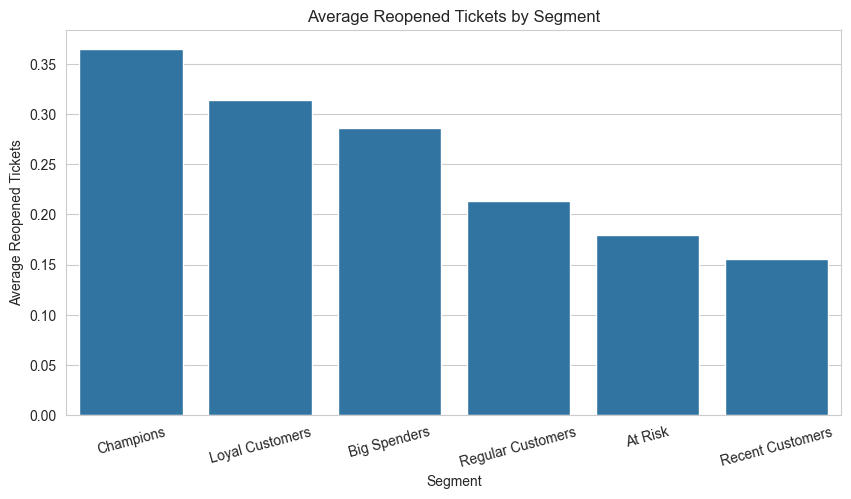

In [36]:
segment_reopened = (
    rfm_support.groupby('Segment')['reopened']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_reopened.index,
    y=segment_reopened.values
)

plt.title("Average Reopened Tickets by Segment")

plt.xlabel("Segment")
plt.ylabel("Average Reopened Tickets")

plt.xticks(rotation=15)

plt.show()

In [37]:
dissatisfied_high_value = rfm_support[
    (rfm_support['Segment'].isin(['Champions', 'Big Spenders'])) &
    (rfm_support['sentiment_score'] < 0)
]

dissatisfied_high_value.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,sentiment_score,reopened,resolution_hours
19,CUST00020,368,3,4487.95,1,3,5,135,Big Spenders,-0.9500,0.0,28.900
29,CUST00030,5,6,3435.59,5,5,4,554,Champions,-0.4150,0.0,27.650
50,CUST00051,210,4,4444.30,1,3,5,135,Big Spenders,-0.3850,0.0,42.200
52,CUST00053,25,4,4192.59,4,3,5,435,Big Spenders,-0.5650,1.0,47.150
74,CUST00075,3,9,6791.61,5,5,5,555,Champions,-0.3525,1.0,27.125


# Retention Prioritization Framework

In [38]:
def retention_priority(row):

    # Highest priority
    if (
        row['Segment'] in ['Champions', 'Big Spenders']
        and row['churn_next_60d'] == 1
    ):
        return "Critical Retention"

    # Silent disengagement
    elif (
        row['Segment'] in ['Champions', 'Loyal Customers']
        and row['last_visit_days_ago'] > 20
    ):
        return "Engagement Recovery"

    # Dissatisfied valuable customers
    elif (
        row['Segment'] in ['Champions', 'Big Spenders']
        and row['sentiment_score'] < 0
    ):
        return "Service Recovery"

    # General at-risk users
    elif row['Segment'] == 'At Risk':
        return "Win-Back Campaign"

    # Recent users
    elif row['Segment'] == 'Recent Customers':
        return "Onboarding & Nurture"

    else:
        return "Regular Engagement"

In [39]:
customer_intelligence = rfm.merge(
    churn_labels[['customer_id', 'churn_next_60d']],
    on='customer_id',
    how='left'
)

customer_intelligence = customer_intelligence.merge(
    web_events,
    on='customer_id',
    how='left'
)

customer_intelligence = customer_intelligence.merge(
    support_summary,
    on='customer_id',
    how='left'
)

customer_intelligence.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,churn_next_60d,...,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,sentiment_score,reopened,resolution_hours
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers,1,...,4,0,0,0,2,0,20,0.14,0.0,4.35
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers,0,...,31,4,2,3,0,0,0,0.00,0.0,1.00
2,CUST00003,171,1,649.98,1,1,1,111,At Risk,1,...,3,0,0,0,0,0,26,NaN,NaN,NaN
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk,1,...,6,0,0,0,0,0,14,NaN,NaN,NaN
4,CUST00005,38,4,2550.91,4,3,3,433,Regular Customers,0,...,95,4,1,1,3,1,9,-1.00,0.0,37.70


In [40]:
customer_intelligence['Retention_Priority'] = (
    customer_intelligence.apply(
        retention_priority,
        axis=1
    )
)

customer_intelligence.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,churn_next_60d,...,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,sentiment_score,reopened,resolution_hours,Retention_Priority
0,CUST00001,107,6,2955.57,2,5,4,254,Loyal Customers,1,...,0,0,0,2,0,20,0.14,0.0,4.35,Regular Engagement
1,CUST00002,40,1,581.00,4,1,1,411,Recent Customers,0,...,4,2,3,0,0,0,0.00,0.0,1.00,Onboarding & Nurture
2,CUST00003,171,1,649.98,1,1,1,111,At Risk,1,...,0,0,0,0,0,26,NaN,NaN,NaN,Win-Back Campaign
3,CUST00004,131,1,1604.04,2,1,3,213,At Risk,1,...,0,0,0,0,0,14,NaN,NaN,NaN,Win-Back Campaign
4,CUST00005,38,4,2550.91,4,3,3,433,Regular Customers,0,...,4,1,1,3,1,9,-1.00,0.0,37.70,Regular Engagement


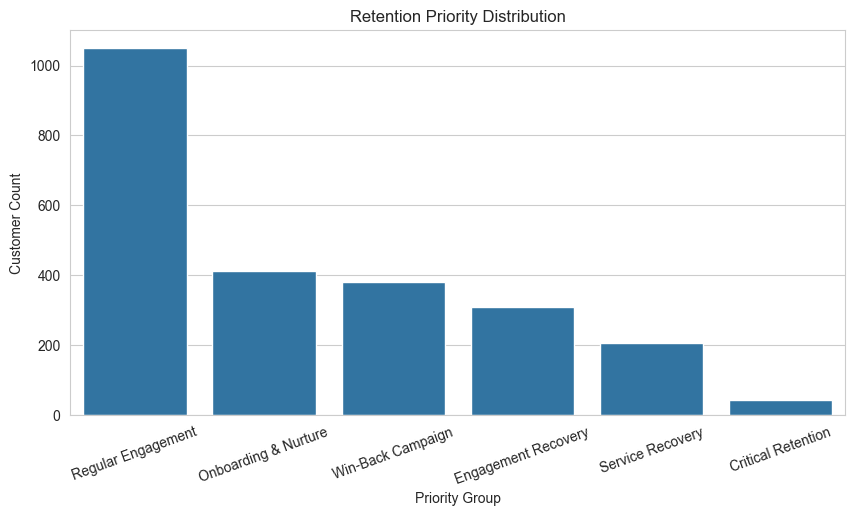

In [41]:
priority_counts = (
    customer_intelligence['Retention_Priority']
    .value_counts()
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=priority_counts.index,
    y=priority_counts.values
)

plt.title("Retention Priority Distribution")

plt.xlabel("Priority Group")
plt.ylabel("Customer Count")

plt.xticks(rotation=20)

plt.show()

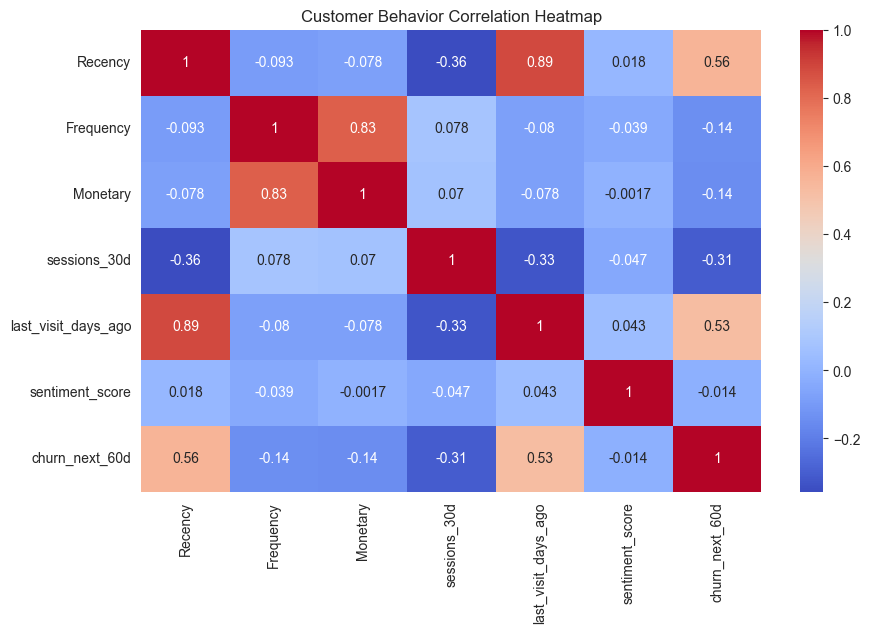

In [42]:
corr_cols = [
    'Recency',
    'Frequency',
    'Monetary',
    'sessions_30d',
    'last_visit_days_ago',
    'sentiment_score',
    'churn_next_60d'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    customer_intelligence[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Customer Behavior Correlation Heatmap")

plt.show()

In [43]:
manual_review_cases = customer_intelligence[
    (
        (customer_intelligence['Segment'] == 'Champions') &
        (customer_intelligence['sessions_30d'] < 5)
    )
    |
    (
        (customer_intelligence['sentiment_score'] < -0.5)
    )
]

manual_review_cases.head(10)

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,churn_next_60d,...,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,sentiment_score,reopened,resolution_hours,Retention_Priority
4,CUST00005,38,4,2550.91,4,3,3,433,Regular Customers,0,...,4,1,1,3,1,9,-1.00,0.0,37.70,Regular Engagement
5,CUST00006,51,5,3770.16,3,4,4,344,Loyal Customers,0,...,1,0,1,0,0,1,-0.68,1.0,17.60,Regular Engagement
12,CUST00013,61,3,1754.44,3,3,3,333,Regular Customers,0,...,1,0,0,2,0,21,-1.00,0.0,74.60,Regular Engagement
19,CUST00020,368,3,4487.95,1,3,5,135,Big Spenders,1,...,0,0,0,0,0,60,-0.95,0.0,28.90,Critical Retention
20,CUST00021,77,2,1059.30,3,2,2,322,Regular Customers,1,...,1,1,0,2,0,18,-0.85,0.0,20.10,Regular Engagement
25,CUST00026,72,3,3561.39,3,3,4,334,Regular Customers,0,...,3,3,0,1,0,26,-0.63,0.0,20.00,Regular Engagement
28,CUST00029,18,8,5252.90,5,5,5,555,Champions,0,...,0,0,0,0,0,0,NaN,NaN,NaN,Regular Engagement
32,CUST00033,12,4,2128.09,5,3,3,533,Regular Customers,0,...,2,2,1,3,0,7,-0.94,0.0,36.35,Regular Engagement
40,CUST00041,54,4,1911.86,3,3,3,333,Regular Customers,1,...,1,1,0,4,2,22,-1.00,0.0,53.00,Regular Engagement
43,CUST00044,72,3,2724.09,3,3,4,334,Regular Customers,0,...,2,1,1,4,2,10,-1.00,1.0,46.70,Regular Engagement


In [44]:
rfm.to_csv(
    "segments.csv",
    index=False
)

print("segments.csv exported successfully")

segments.csv exported successfully
